In [1]:
from sklearn.datasets import make_circles
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import numpy as np

from DataVisualization import PlotBinaryClassData

In [2]:
numCircles0 = 250
numCircles1 = 250
noiseLevel = 0.03
numSwaps = 50 # number of points which are swaped 
numGridPts = 250

seedNum = 512

In [3]:
numCircles = numCircles0 + numCircles1
mX, vY = make_circles((numCircles0, numCircles1), shuffle=False, noise=noiseLevel, random_state=seedNum)
print(f"The features data shape: {mX.shape}")
print(f"The labels data shape: {vY.shape}")

The features data shape: (500, 2)
The labels data shape: (500,)


In [4]:
vSwapIdx = np.random.choice(numCircles0, numSwaps, replace=False)
vY[vSwapIdx] = 1

vSwapIdx = numCircles0 + np.random.choice(numCircles1, numSwaps,replace= False)
vY[vSwapIdx] = 0 

In [5]:
mX, vY = make_circles((250, 250), shuffle=False, noise=0.03, random_state=seedNum)
idxs_to_swap = np.random.choice(a=250, size=50, replace=False)
vY[idxs_to_swap] = 1
idxs_to_swap = 250 + np.random.choice(a=250, size=50, replace=False)

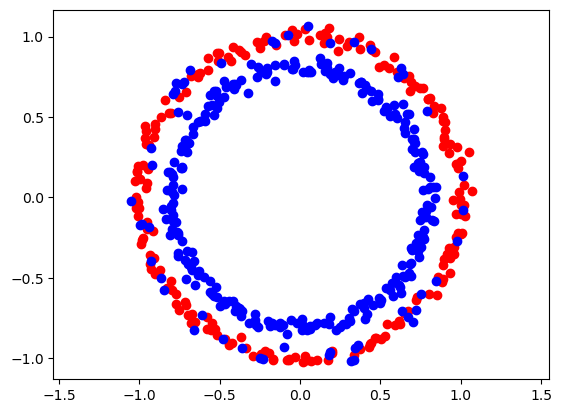

In [6]:
plt.scatter(mX[vY==0][:, 0], mX[vY==0][:, 1], marker='o', color = 'red')
plt.scatter(mX[vY==1][:, 0], mX[vY==1][:, 1], marker='o', color = 'blue')
plt.axis('equal')
plt.show()

In [7]:
v0 = np.linspace(mX[:, 0].min() - 0.1, mX[:, 0].max() + 0.1, numGridPts)
v1 = np.linspace(mX[:, 1].min() - 0.1, mX[:, 1].max() + 0.1, numGridPts)

XX0, XX1 = np.meshgrid(v0, v1)
XX = np.c_[XX0.ravel(), XX1.ravel()]
XX

array([[-1.15451137, -1.12757644],
       [-1.14516321, -1.12757644],
       [-1.13581504, -1.12757644],
       ...,
       [ 1.15448502,  1.16315319],
       [ 1.16383318,  1.16315319],
       [ 1.17318135,  1.16315319]], shape=(62500, 2))

In [38]:
from ipywidgets import interact, IntSlider, Dropdown

In [9]:
import ipywidgets as widgets

In [10]:
def plot_knn(K):

    oKNNClassifier = KNeighborsClassifier(n_neighbors=K, p=2).fit(mX, vY)
    Z = oKNNClassifier.predict(XX)
    Z = Z.reshape(XX0.shape)

    fig, ax = plt.subplots()

    plt.scatter(mX[vY==0][:, 0], mX[vY==0][:, 1], marker='o', color = 'red')
    plt.scatter(mX[vY==1][:, 0], mX[vY==1][:, 1], marker='o', color = 'blue')
    # in plt.contourf levels = [-0.5, 0.5, 1.5] creates two regions one between -0.5 and 0.5 actually zero, and the second between 0.5 and 1.5 which is actually 1
    plt.contourf(XX0, XX1, Z, colors= ['red', 'blue'], alpha = 0.2, levels = [-0.5, 0.5, 1.5])
    plt.title(f"{K}-NN Classifier, Acuracy: {oKNNClassifier.score(mX, vY)}")
    plt.axis('equal')
    plt.show()



In [11]:
interact(
    plot_knn,
    K = IntSlider(
        value = 1, 
        min = 1, 
        max = 7,
        step = 1,
        description = "K"
    )

)

interactive(children=(IntSlider(value=1, description='K', max=7, min=1), Output()), _dom_classes=('widget-inte…

<function __main__.plot_knn(K)>

In [12]:
from sklearn.datasets import load_breast_cancer

In [13]:
dData = load_breast_cancer()
mX = dData.data
vY = dData.target
features_names = dData.feature_names

In [14]:
np.unique(vY, return_counts=True)

(array([0, 1]), array([212, 357]))

In [15]:
# Normalization of features_names
mX = (mX - np.min(mX, axis=0)) / (np.max(mX, axis=0) - np.min(mX, axis=0))

(array([  2.,  26., 110., 160., 164.,  79.,  20.,   5.,   2.,   1.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

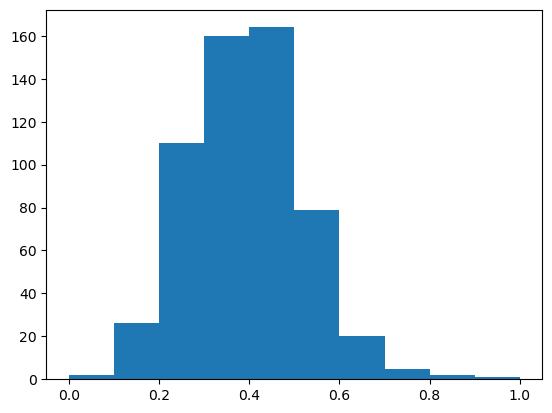

In [16]:
# sanity check for distribution of the specific feature after normalization
plt.hist(mX[:, 4])

In [17]:
from numpy.typing import NDArray


In [18]:
dict_metric = {
    'l1' : 'L1',
    'l2' : 'L2',
    'cosine' : 'Cosine'
}

dict_feature_by_indx = {}
dict_feature_by_name = {}

for ii, name in enumerate(features_names):
    dict_feature_by_indx[ii] = name
    dict_feature_by_name[name] = ii


In [49]:
def plot_knn(K: int, metricChoice:str, mX: NDArray, vY: NDArray, feature_X_name:str, feature_Y_name:str) -> None:
    list_clf_feature = [dict_feature_by_name[feature_X_name], dict_feature_by_name[feature_Y_name]]

    knn_clf = KNeighborsClassifier(n_neighbors=K, metric=metricChoice)
    knn_clf = knn_clf.fit(mX, vY)

    vYY = knn_clf.predict(mX)
    scoreAcc =  knn_clf.score(mX, vY)

    fig, ax = plt.subplots(figsize = (6, 6))

    # plotting of data
    ax.scatter(
        mX[vY == 0][:, dict_feature_by_name[feature_X_name]],
        mX[vY == 0][:, dict_feature_by_name[feature_Y_name]],
        marker = 'o',
        color = 'red',
        s=45
    )
    ax.scatter(
        mX[vY == 1][:, dict_feature_by_name[feature_X_name]],
        mX[vY == 1][:, dict_feature_by_name[feature_Y_name]],
        marker = 'o',
        color = 'blue',
        s=45
    )

    ax.scatter(
        mX[vYY == 0][:, dict_feature_by_name[feature_X_name]],
        mX[vYY == 0][:, dict_feature_by_name[feature_Y_name]],
        marker = 'o',
        color = 'red',
        edgecolors='k',
        s=200,
        alpha=0.4
    )

    ax.scatter(
        mX[vYY == 1][:, dict_feature_by_name[feature_X_name]],
        mX[vYY == 1][:, dict_feature_by_name[feature_Y_name]],
        marker = 'o',
        color = 'blue',
        edgecolors='k',
        s=200,
        alpha=0.4
    )
    ax.set_title(f'{K}-NN Mapping of cells, accuracy: {scoreAcc:.2f}')
    ax.set_xlabel(f"{feature_X_name}")
    ax.set_ylabel(f"{feature_Y_name}")

    plt.show()    

In [ ]:
K_slider = widgets.Inti












fgsdfg1. asdfasdfasdfsdfgsdfgkasdfkljsfadjklfdaSlider(value=3, min=1, max=21, step=1, description = 'K neighbours')
Metric_menu = widgets.Dropdown(options = ['l1', 'l2', 'cosine'], value = 'l1', description="metric")
X_axis_menu = widgets.Dropdown(options = features_names, value = features_names[0], description = 'X-axis feature')
Y_axis_menu = widgets.Dropdown(options = features_names, value = features_names[1], description = 'Y-axis feature')

In [ ]:
interact(
    lambda K, metricChoice, feature_X_name, feature_Y_name: plot_knn(K=K, metricChoice=metricChoice, mX= mX, vY=vY,feature_X_name= feature_X_name, feature_Y_name=feature_Y_name),
    K = K_slider,
    feature_X_name = X_axis_menu,
    feature_Y_name = Y_axis_menu,
    metricChoice = Metric_menu
    )


interactive(children=(IntSlider(value=3, description='K neighbours', max=21, min=1), Dropdown(description='met…

<function __main__.<lambda>(K, metricChoice, feature_X_name, feature_Y_name)>